                Open      High       Low     Close      MA_10       MA_20  \
Date                                                                        
2020-12-29  14567.30  14626.53  14511.96  14590.32  14309.142  14134.8870   
2020-12-30  14646.29  14653.22  14518.81  14639.19  14353.053  14181.6440   
2020-12-31  14643.69  14681.65  14598.91  14640.61  14385.113  14227.9820   
2021-01-01  14651.85  14711.52  14646.97  14680.13  14416.020  14275.2655   
2021-01-04  14757.89  14816.98  14615.79  14803.19  14456.579  14322.1590   

            Daily_Return  Volatility     Lag_1     Lag_2  
Date                                                      
2020-12-29      0.004474  193.484040  14525.34  14397.03  
2020-12-30      0.003349  214.652191  14590.32  14525.34  
2020-12-31      0.000097  232.378719  14639.19  14590.32  
2021-01-01      0.002699  250.174148  14640.61  14639.19  
2021-01-04      0.008383  278.167600  14680.13  14640.61  


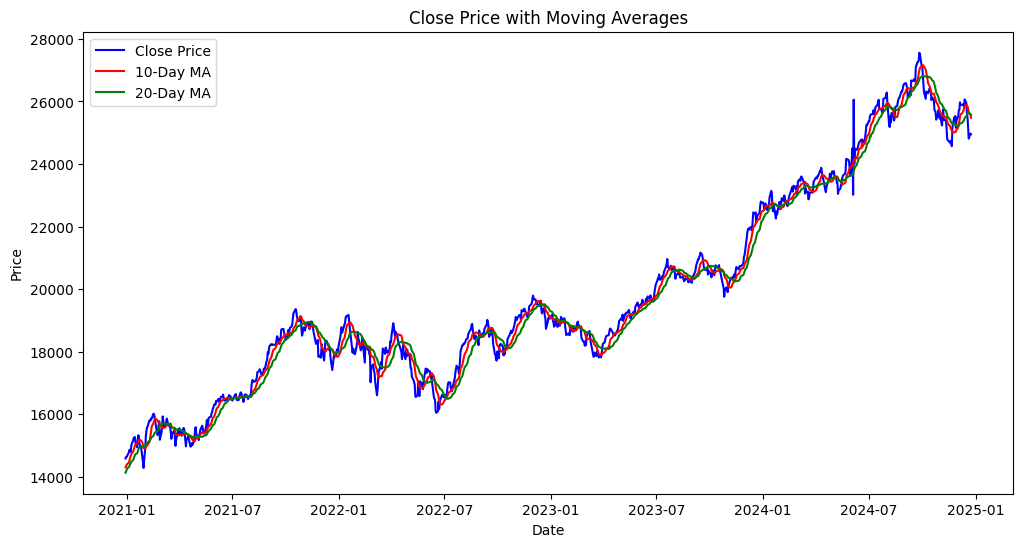

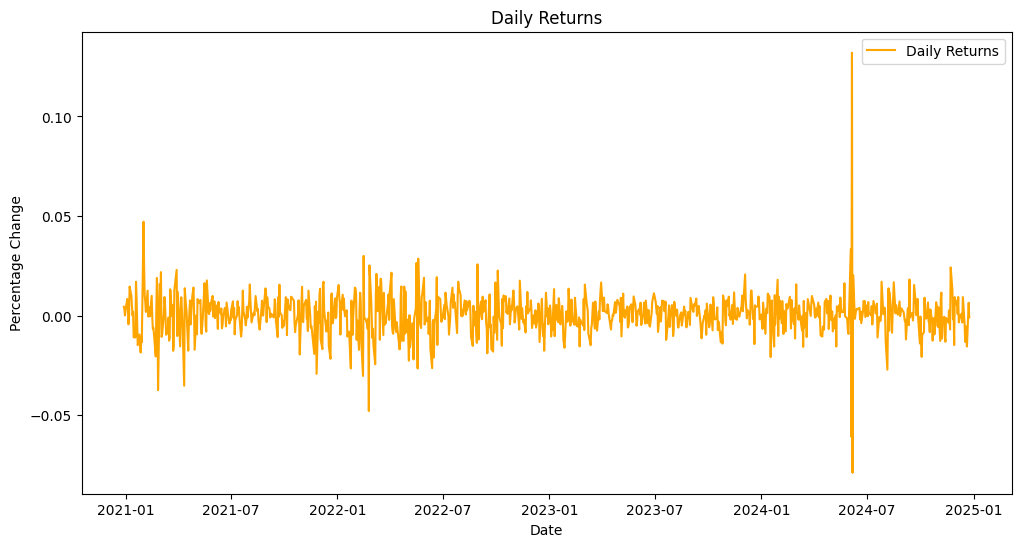

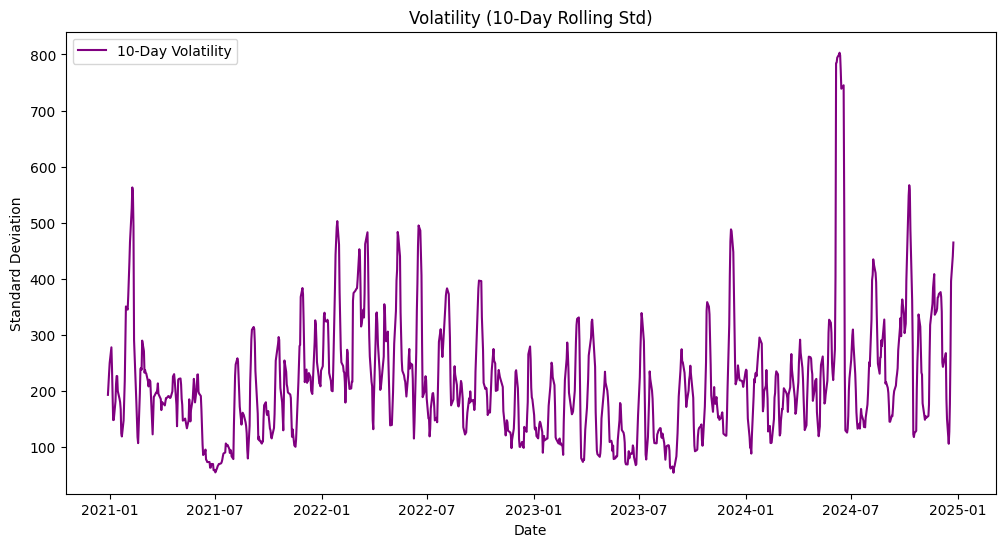

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('/Users/suryanshu/Downloads/SPBSS5IP_01122020_25122024.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

# 1. Calculate Moving Averages
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()

# 2. Calculate Daily Returns
data['Daily_Return'] = data['Close'].pct_change()

# 3. Calculate Volatility (Standard Deviation over a 10-day window)
data['Volatility'] = data['Close'].rolling(window=10).std()

# 4. Create Lag Features
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)

# Drop NaN values generated due to rolling calculations
data.dropna(inplace=True)

# Display the first few rows of the new data
print(data.head())

# 5. Plot Moving Averages and Close Price
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['MA_10'], label='10-Day MA', color='red')
plt.plot(data['MA_20'], label='20-Day MA', color='green')
plt.title('Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 6. Plot Daily Returns
plt.figure(figsize=(12, 6))
plt.plot(data['Daily_Return'], label='Daily Returns', color='orange')
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.legend()
plt.show()

# 7. Plot Volatility
plt.figure(figsize=(12, 6))
plt.plot(data['Volatility'], label='10-Day Volatility', color='purple')
plt.title('Volatility (10-Day Rolling Std)')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.show()